# Robustness Analysis for Monetary Reputation Model

This notebook performs a sensitivity analysis by comparing the baseline calibration
against alternative parameter values. For each alternative specification, it:
1. Solves the dynamic game with the modified parameter
2. Plots price levels and optimal policies against the baseline
3. Visualizes how equilibrium outcomes change with different parameters


In [1]:
using Plots 
include("model_solver.jl")

ergodic_inflation (generic function with 1 method)

In [2]:
# Convergence tolerance for all solutions
tol = 1e-5

1.0e-5

## Baseline Calibration

This represents the main specification used in the analysis.

In [3]:
baseline_params = (;
        epsilon = 0.02,      # Probability type 2 becomes type 1
        delta = 0.02,        # Probability type 1 becomes type 2

        sigma = 5.0,         # Elasticity of substitution
        beta = 0.99,         # Discount factor

        gammas = (;  π_target_1 = 0.02,  # inflation if only type 1 
                     π_target_2 = 0.03),  # inflation if only type 2  
)

baseline_struct = ModelParameters(; baseline_params...)

ModelParameters{Float64, var"#ModelParameters##6#ModelParameters##7", var"#ModelParameters##8#ModelParameters##9", var"#ModelParameters##10#ModelParameters##11"}(Distribution{Float64}([0.0, 0.0002501250625312656, 0.0005002501250625312, 0.0007503751875937969, 0.0010005002501250625, 0.0012506253126563281, 0.0015007503751875938, 0.0017508754377188595, 0.002001000500250125, 0.0022511255627813906  …  0.4977488744372186, 0.49799899949974985, 0.49824912456228115, 0.4984992496248124, 0.49874937468734365, 0.49899949974987495, 0.4992496248124062, 0.49949974987493745, 0.49974987493746875, 0.5], [0.0062336395407496656, 0.006194781422734235, 0.006156165531322673, 0.006117790356567238, 0.006079654397932619, 0.006041756164237271, 0.006004094173595099, 0.00596666695335752, 0.005929473040055877, 0.005892510979344215  …  2.4575476493494146e-8, 2.4422282398836116e-8, 2.4270043257407346e-8, 2.411875311639568e-8, 2.3968406060096488e-8, 2.38189962096814e-8, 2.3670517722968388e-8, 2.3522964794193358e-8, 2.33

In [4]:
baseline_gammas = (; gammas = (; gamma1 = baseline_struct.inflation_costs.gamma1,
                    gamma2 = baseline_struct.inflation_costs.gamma2))

(gammas = (gamma1 = 0.017073194732354285, gamma2 = 0.009233406982354848),)

In [5]:
# Solve the baseline model
println("Computing baseline solution...")
@time optimal_policies_baseline, dynamics_baseline, diff = solve_dynamic_game(baseline_struct; tol, verbose = false)
baseline_reference = solve_reference_game(baseline_struct)
println("      converge error: $diff. ")
println("Done.")

Computing baseline solution...
 17.212858 seconds (1.58 G allocations: 64.525 GiB, 20.86% gc time, 62.80% compilation time)
      converge error: 9.926685453853779e-6. 
Done.


## Alternative Parameter Specifications

Each tuple specifies a single parameter deviation from baseline for sensitivity analysis.

In [6]:
exercises = [
    (; gammas = (; π_target_1 = 0.025, π_target_2 = 0.03)),   # Lower cost for type 1 (more willing to inflate)
    (; gammas = (; π_target_1 = 0.02, π_target_2 = 0.035)),   #  Lower cost for type 2 (more willing to inflate)
    (; delta = 0.05),     # Higher probability type 1 switches to type 2
    (; epsilon = 0.05),   # Higher probability type 2 switches to type 1
    (; sigma = 4.0),      # Lower elasticity of substitution
    (; beta = 0.96),      # Lower discount factor (more impatient)
    (; delta = 0.9)       # Very high transition probability (extreme case)
]

7-element Vector{NamedTuple}:
 (gammas = (π_target_1 = 0.025, π_target_2 = 0.03),)
 (gammas = (π_target_1 = 0.02, π_target_2 = 0.035),)
 (delta = 0.05,)
 (epsilon = 0.05,)
 (sigma = 4.0,)
 (beta = 0.96,)
 (delta = 0.9,)

## Robustness Analysis Loop

For each alternative specification, solve the model and compare against baseline.

Running robustness check with parameters: (gammas = (π_target_1 = 0.025, π_target_2 = 0.03),)
 18.957753 seconds (1.59 G allocations: 64.846 GiB, 26.24% gc time)
     converge error: 9.997313061171909e-6. 
Done.
Running robustness check with parameters: (gammas = (π_target_1 = 0.02, π_target_2 = 0.035),)
 36.011841 seconds (2.32 G allocations: 94.724 GiB, 33.31% gc time)
     converge error: 9.539493010302103e-6. 
Done.
Running robustness check with parameters: (delta = 0.05,)
 24.766389 seconds (1.58 G allocations: 64.470 GiB, 31.08% gc time)
     converge error: 9.946534448301847e-6. 
Done.
Running robustness check with parameters: (epsilon = 0.05,)
 23.994333 seconds (1.57 G allocations: 64.282 GiB, 30.45% gc time)
     converge error: 9.910542612567852e-6. 
Done.
Running robustness check with parameters: (sigma = 4.0,)
 31.296459 seconds (1.77 G allocations: 72.550 GiB, 33.55% gc time)
     converge error: 9.951872752766988e-6. 
Done.
Running robustness check with parameters: (beta

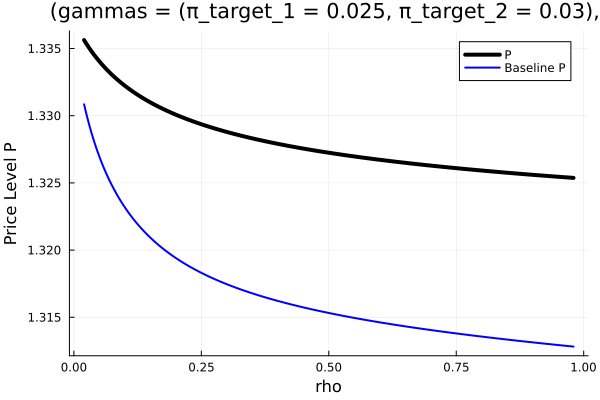

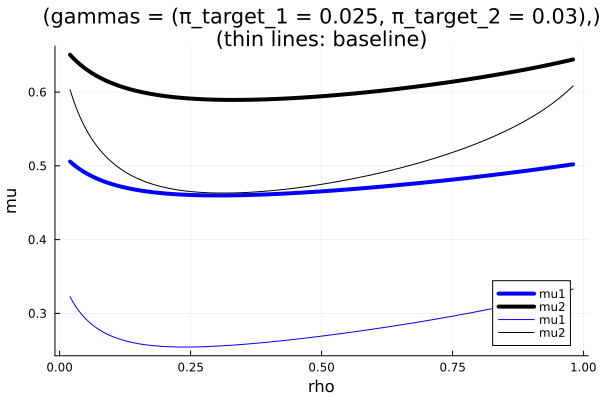

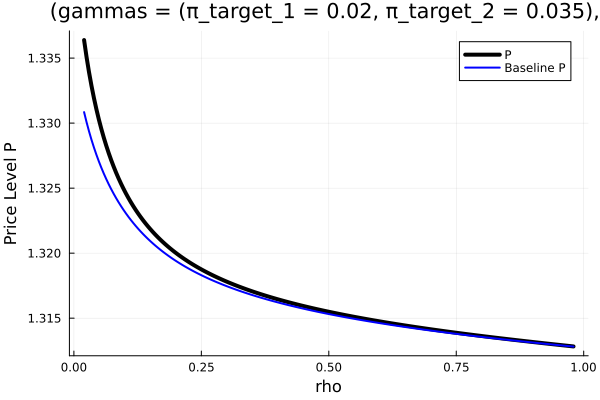

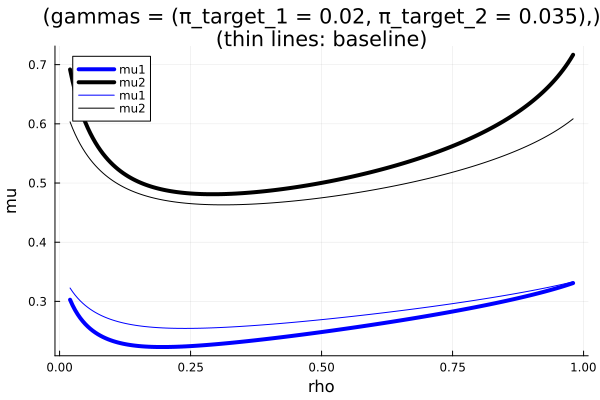

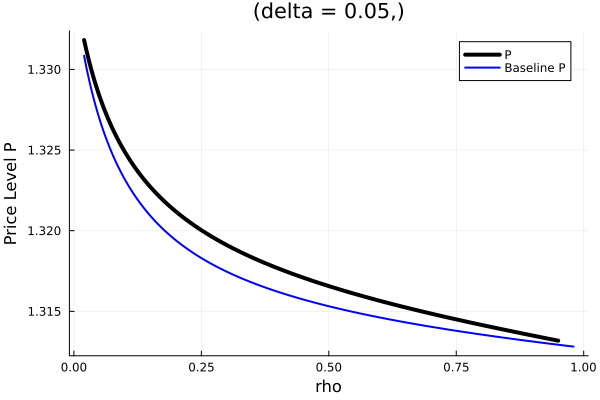

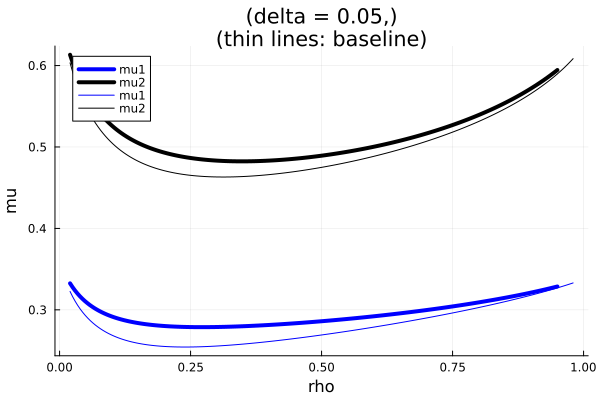

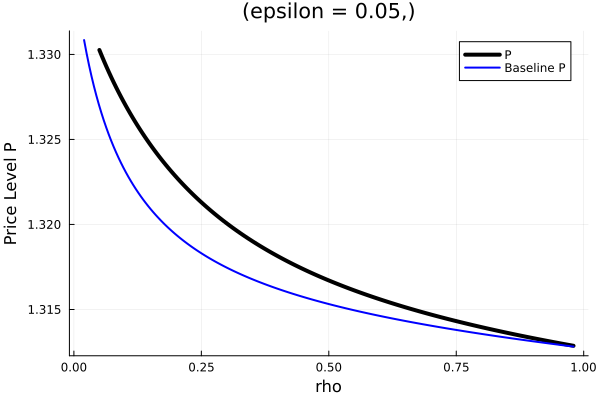

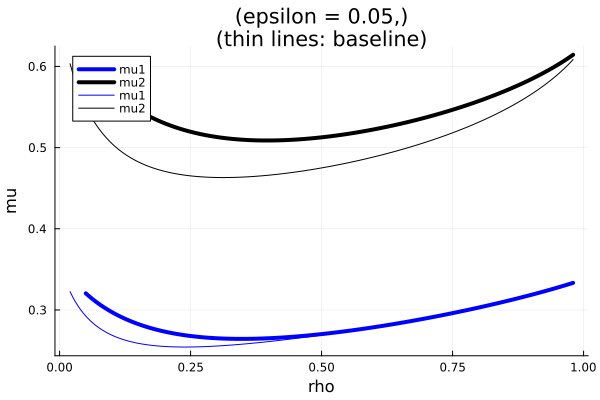

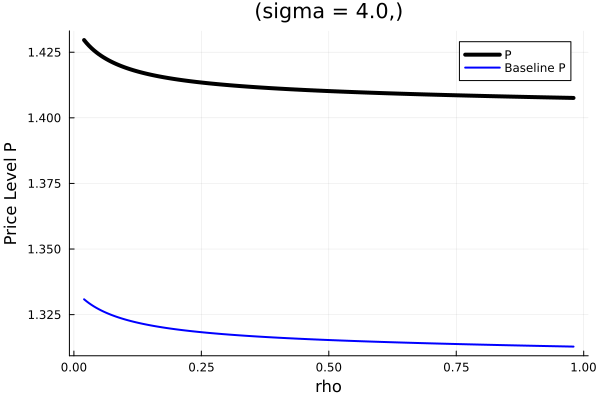

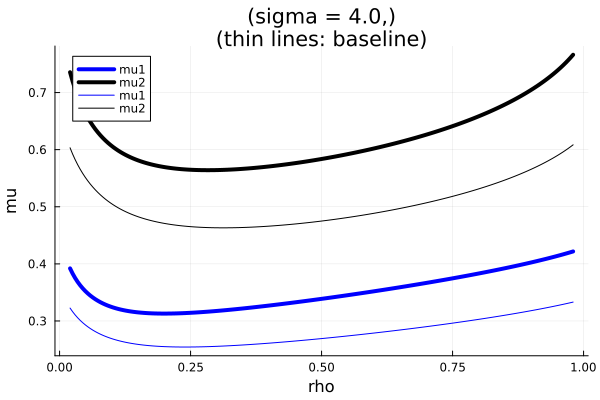

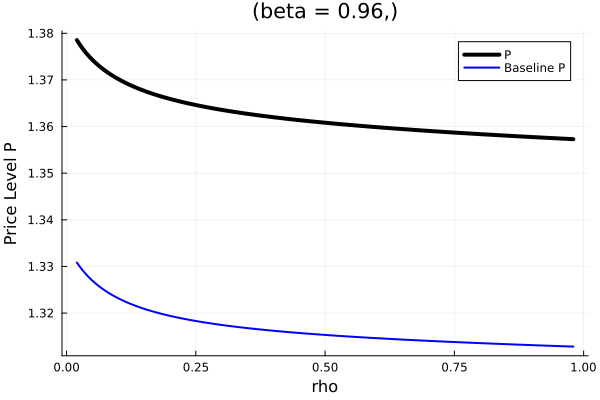

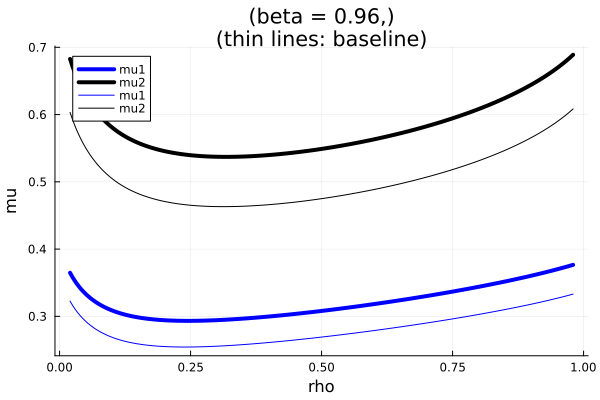

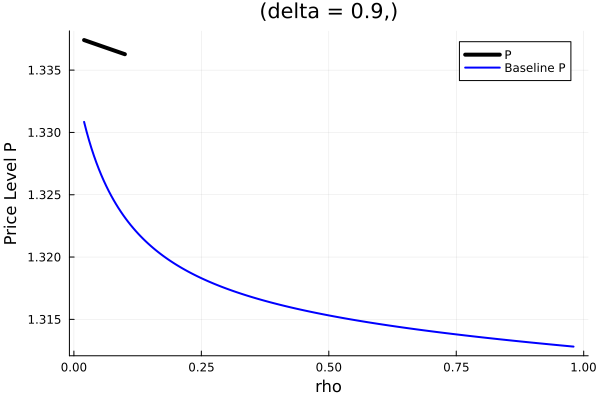

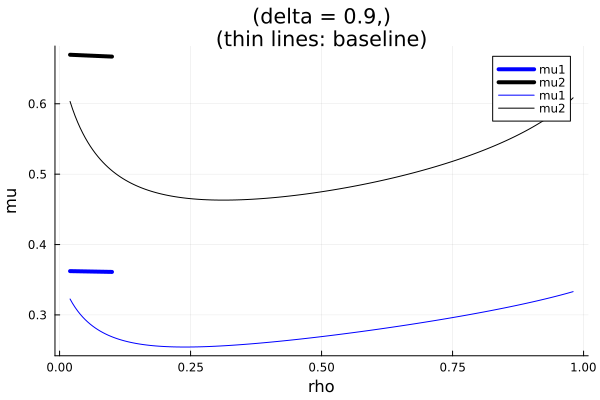

In [7]:
for alternative in exercises
    # Create parameters with one deviation from baseline
    alternative_params = ModelParameters(;  baseline_params..., baseline_gammas..., alternative...)
    
    println("Running robustness check with parameters: $alternative")

    # Solve the dynamic game for this specification
    @time alternative_policies, alternative_dynamics, alternative_err = solve_dynamic_game(alternative_params; tol, verbose = false)
    alternative_reference = solve_reference_game(alternative_params)

    println("     converge error: $alternative_err. ")
    println("Done.")

    
    # Plot 1: Price Level Comparison
    # Shows how the price level P varies with reputation (rho) under the
    # alternative specification vs. baseline
    local f1 = plot( xlabel="rho", ylabel="Price Level P", title="$alternative")


    plot!(f1, get_rho_grid(alternative_params), alternative_policies.P, linewidth = 4, label = "P", color = :black)
    plot!(f1, get_rho_grid(baseline_struct), optimal_policies_baseline.P, linewidth = 2, label = "Baseline P", color = :blue)

    # Plot 2: Optimal Policy Comparison
    # Shows optimal money injection policies for both types across reputation levels
    local f2 = plot(xlabel="rho", ylabel="mu", title="$alternative\n(thin lines: baseline)")
    
    plot!(f2, get_rho_grid(alternative_params), alternative_policies.mu1_pol, linewidth = 4, color= :blue, label = "mu1" )
    plot!(f2, get_rho_grid(alternative_params), alternative_policies.mu2_pol, linewidth = 4, color= :black, label = "mu2")
    plot!(f2, get_rho_grid(baseline_struct), optimal_policies_baseline.mu1_pol, label = "mu1", color = :blue, linewidth = 1)
    plot!(f2, get_rho_grid(baseline_struct), optimal_policies_baseline.mu2_pol, label = "mu2", color = :black, linewidth = 1)
    

    # Display plots for visual comparison
    display(f1)
    display(f2)
end